# What are the most demanded skills for the top 3 most popular data roles?

### Methodology
1. Clean-up skill Column
2. Calculate skill count base on job_title_short
3. Calculate skill percentage
4. plot final findings

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"], errors="coerce")
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [9]:
df_CA = df[df["job_country"] == "Canada"]

In [11]:
df_skills = df_CA.explode("job_skills")

df_skills[["job_title", "job_skills"]]

,job_title,job_skills
50,Sr ML Engineer - Research & NLP (Remote),python
50,Sr ML Engineer - Research & NLP (Remote),sql
50,Sr ML Engineer - Research & NLP (Remote),pytorch
50,Sr ML Engineer - Research & NLP (Remote),pandas
59,Data Engineer with Dremio Experience,sql
...,...,...
785511,Data Engineer,spark
785511,Data Engineer,airflow
785511,Data Engineer,kafka
785643,Analyste,word


In [34]:
df_job_total_count = df_CA["job_title_short"].value_counts().reset_index(name="jobs_total")

In [15]:
df_skill_count = df_skills.groupby(["job_skills", "job_title_short"]).size().reset_index(name="count").sort_values(by="count", ascending=False)
df_skill_count

,job_skills,job_title_short,count
1215,sql,Data Engineer,3794
949,python,Data Engineer,3567
108,azure,Data Engineer,2217
98,aws,Data Engineer,2030
1171,spark,Data Engineer,1948
...,...,...,...
749,no-sql,Cloud Engineer,1
748,no-sql,Business Analyst,1
671,mattermost,Senior Data Analyst,1
1439,webex,Data Scientist,1


In [38]:
df_skill_perc = pd.merge(df_skill_count, df_job_total_count, how="left", on="job_title_short")
df_skill_perc["job_skills_percent"] = (df_skill_perc["count"] / df_skill_perc["jobs_total"]) * 100
df_skill_perc

,job_skills,job_title_short,count,jobs_total,job_skills_percent
0,sql,Data Engineer,3794,5828,65.099520
1,python,Data Engineer,3567,5828,61.204530
2,azure,Data Engineer,2217,5828,38.040494
3,aws,Data Engineer,2030,5828,34.831846
4,spark,Data Engineer,1948,5828,33.424846
...,...,...,...,...,...
1480,no-sql,Cloud Engineer,1,282,0.354610
1481,no-sql,Business Analyst,1,1109,0.090171
1482,mattermost,Senior Data Analyst,1,435,0.229885
1483,webex,Data Scientist,1,1825,0.054795


In [21]:
job_titles = df_skill_count["job_title_short"].unique().tolist()
job_titles = sorted(job_titles[:5])
job_titles

['Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'Senior Data Engineer',
 'Software Engineer']

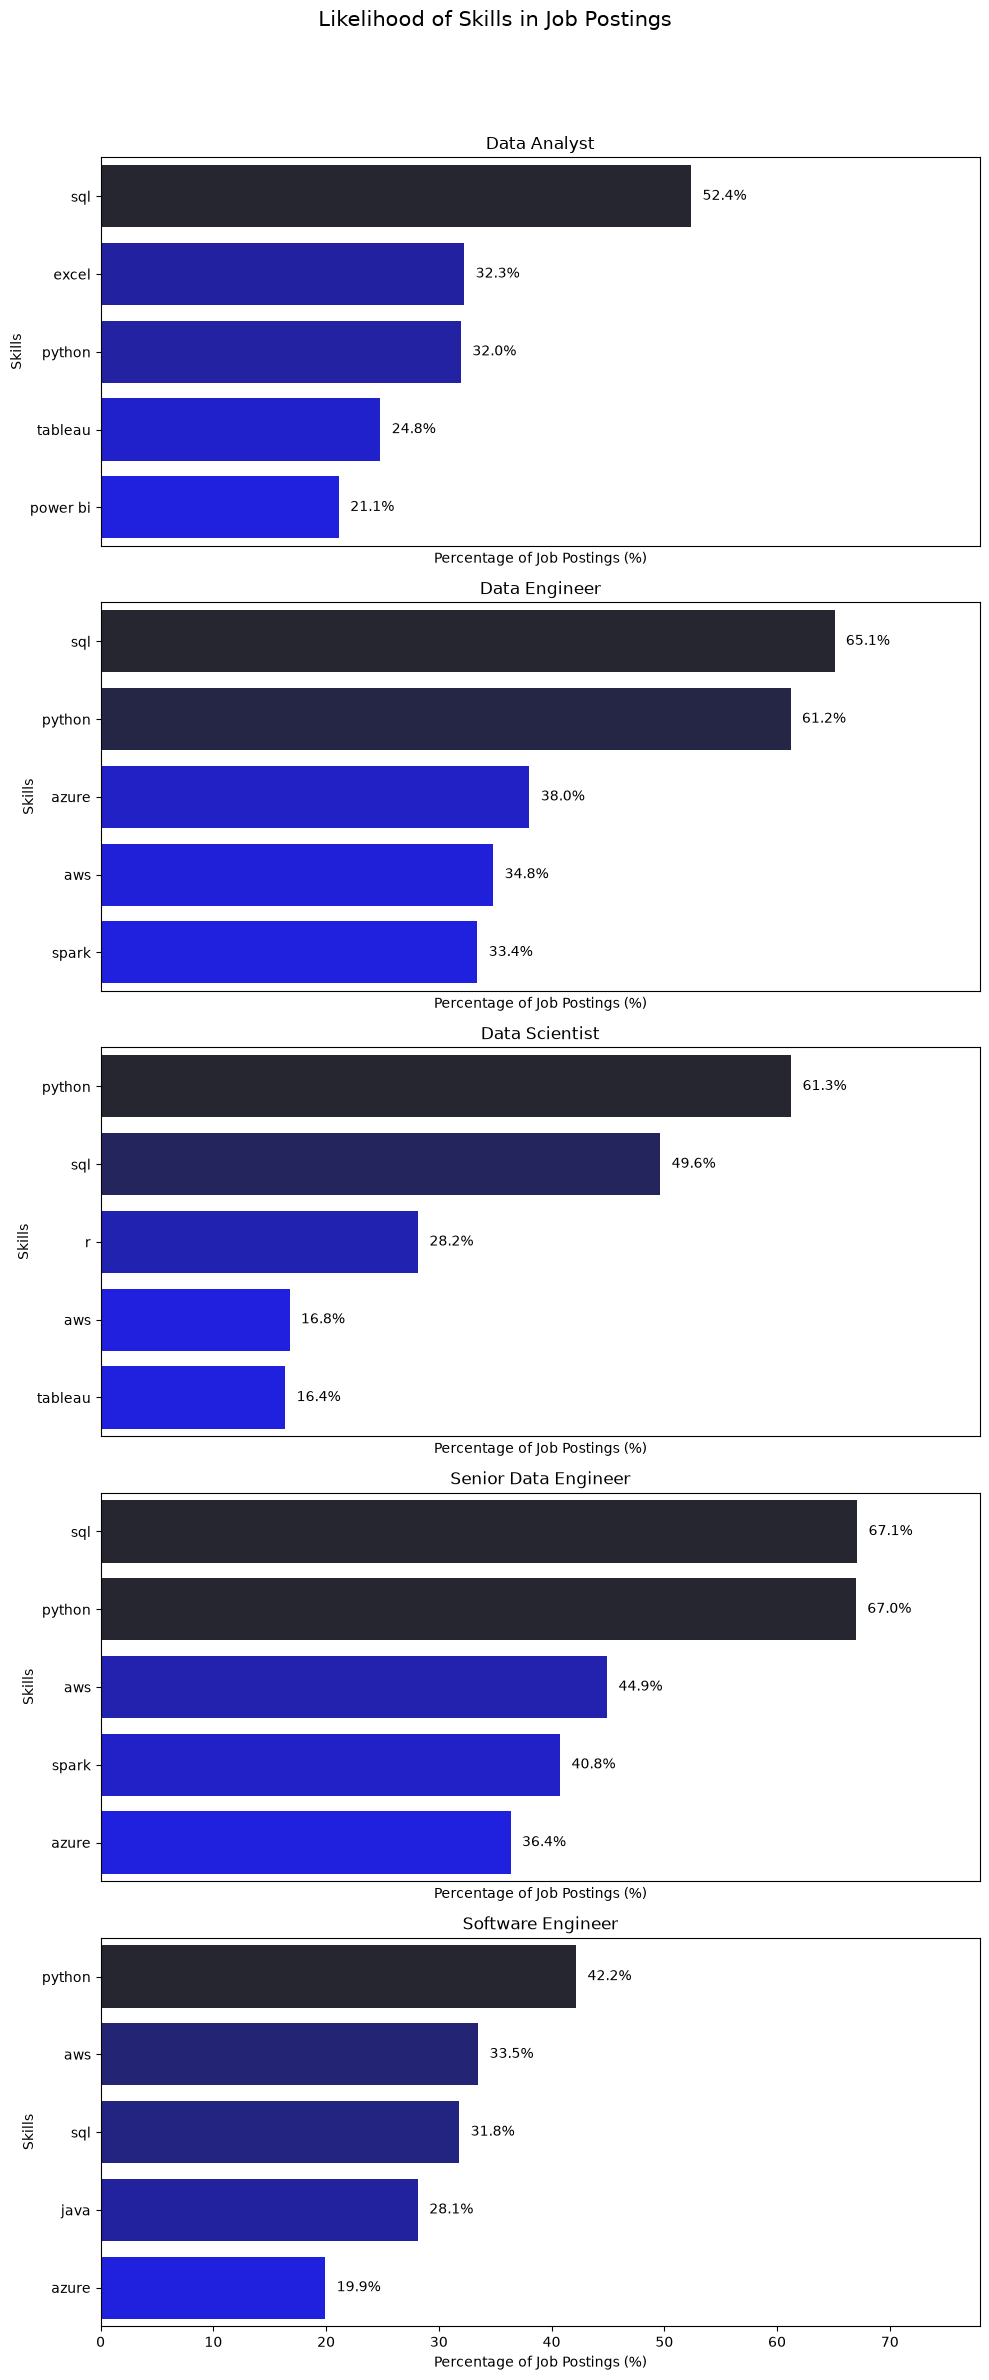

In [59]:
fig, axes = plt.subplots(len(job_titles), 1, figsize=(10, 5 * len(job_titles)))

for i, job_title in enumerate(job_titles):
    df_plot = df_skill_perc[df_skill_perc["job_title_short"] == job_title].head(5)
    #df_plot.plot(kind="barh", x="job_skills", y="job_skills_percent", ax=axes[i], legend=False, title =job_title)
    sns.barplot(data=df_plot, x='job_skills_percent', y='job_skills', hue='job_skills_percent', palette='dark:b_r', legend=False, ax=axes[i])
    axes[i].set_title(job_title)
    axes[i].set_xlabel("Percentage of Job Postings (%)")
    axes[i].set_ylabel("Skills")
    axes[i].set_xlim(0, 78)

    for n, v in enumerate(df_plot["job_skills_percent"]):
        axes[i].text(v + 1, n, f"{v:.1f}%", va="center")
    
    if i != len(job_titles) - 1:
        axes[i].set_xticks([])



fig.suptitle("Likelihood of Skills in Job Postings", fontsize=15)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
